Cargando dataset limpio...


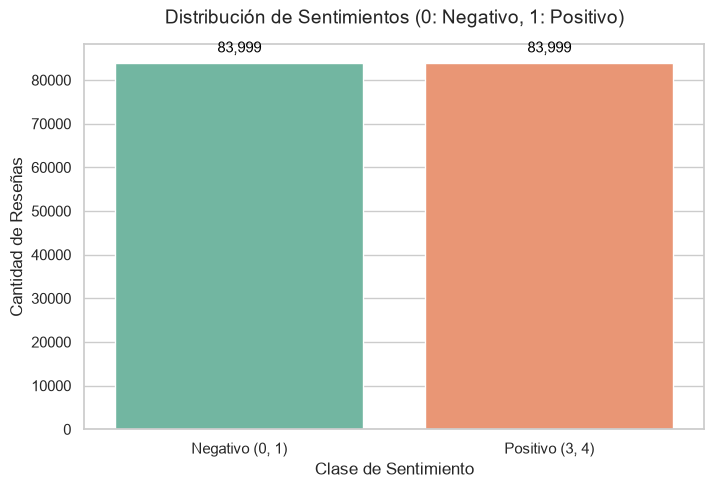

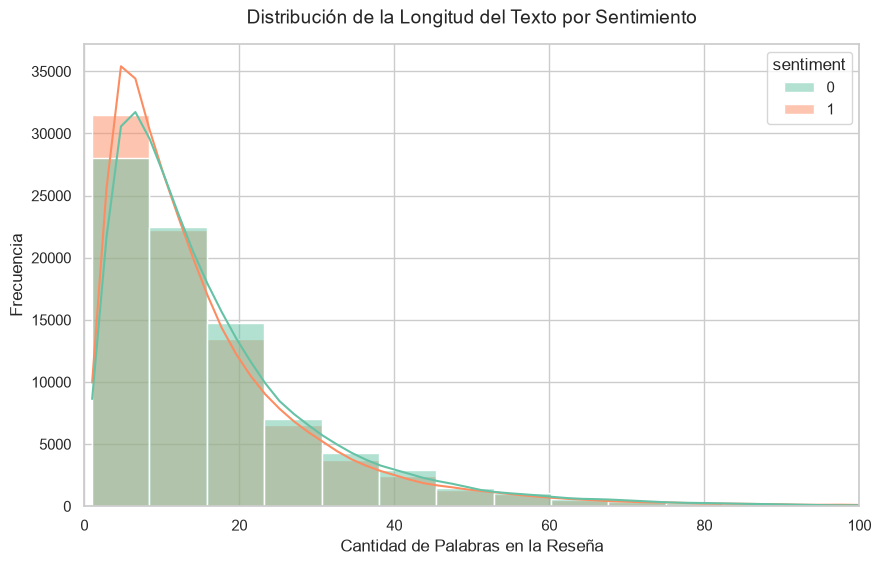

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1. Cargar el dataset LIMPIO que generamos recién
print("Cargando dataset limpio...")
df = pd.read_csv('../data/processed/amazon_reviews_clean.csv')

# Configurar el estilo visual
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# GRÁFICO 1: Balance de clases (Sentimiento)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='sentiment', palette='Set2', hue='sentiment', legend=False)
plt.title('Distribución de Sentimientos (0: Negativo, 1: Positivo)', fontsize=14, pad=15)
plt.xlabel('Clase de Sentimiento', fontsize=12)
plt.ylabel('Cantidad de Reseñas', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Negativo (0, 1)', 'Positivo (3, 4)'])

# Agregar los números exactos arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()


# ---------------------------------------------------------
# GRÁFICO 2: Distribución de la longitud de las reseñas
# ---------------------------------------------------------
# Calcular cantidad de palabras por cada reseña procesada
df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='sentiment', bins=50, kde=True, palette='Set2')
plt.title('Distribución de la Longitud del Texto por Sentimiento', fontsize=14, pad=15)
plt.xlabel('Cantidad de Palabras en la Reseña', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
# Limitamos el eje X a 100 palabras para evitar que valores atípicos extremos deformen el gráfico
plt.xlim(0, 100) 
plt.show()

=== METRICAS DEL CORPUS LIMPIO ===
Total de tokens: 2,796,868
Vocabulario unico: 53,640
Type-Token Ratio (TTR): 0.0192


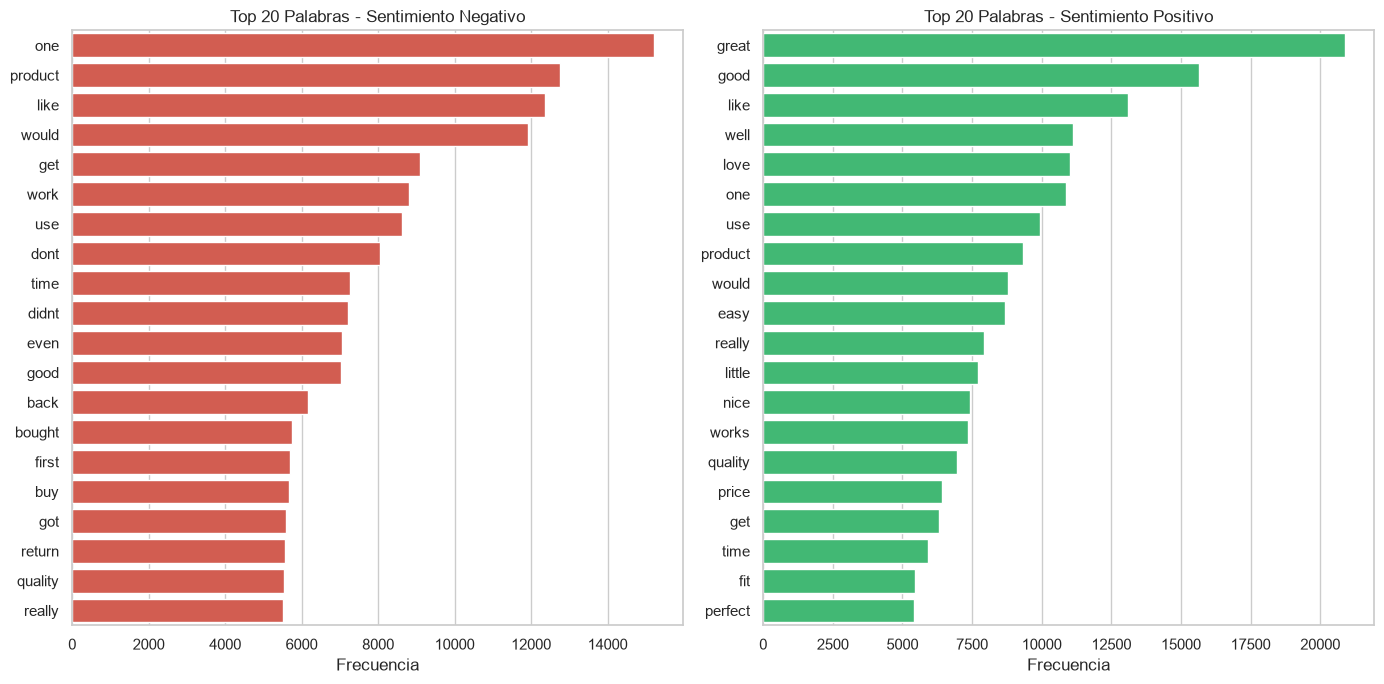

In [7]:
# Agrupacion de todos los tokens del corpus procesado.
all_tokens = " ".join(df["cleaned_text"].astype(str)).split()
total_tokens = len(all_tokens)
unique_vocab = len(set(all_tokens))
ttr = unique_vocab / total_tokens

# Presentacion de metricas calculadas.
print("=== METRICAS DEL CORPUS LIMPIO ===")
print(f"Total de tokens: {total_tokens:,}")
print(f"Vocabulario unico: {unique_vocab:,}")
print(f"Type-Token Ratio (TTR): {ttr:.4f}")

# Separacion de tokens por polaridad.
neg_tokens = " ".join(df[df["sentiment"] == 0]["cleaned_text"].astype(str)).split()
pos_tokens = " ".join(df[df["sentiment"] == 1]["cleaned_text"].astype(str)).split()

# Extraccion de las veinte palabras mas frecuentes.
top_neg = pd.DataFrame(Counter(neg_tokens).most_common(20), columns=["word", "frequency"])
top_pos = pd.DataFrame(Counter(pos_tokens).most_common(20), columns=["word", "frequency"])

# Creacion de dos lienzos independientes para cada grafico.
fig, (ax_neg, ax_pos) = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

# Grafico de barras para resenas negativas.
sns.barplot(data=top_neg, y="word", x="frequency", ax=ax_neg, color="#e74c3c")
ax_neg.set_title("Top 20 Palabras - Sentimiento Negativo", fontsize=12)
ax_neg.set_xlabel("Frecuencia")
ax_neg.set_ylabel("")

# Grafico de barras para resenas positivas.
sns.barplot(data=top_pos, y="word", x="frequency", ax=ax_pos, color="#2ecc71")
ax_pos.set_title("Top 20 Palabras - Sentimiento Positivo", fontsize=12)
ax_pos.set_xlabel("Frecuencia")
ax_pos.set_ylabel("")

plt.tight_layout()
plt.show()